# Portfolio Analysis

## 1. Data
Pull historical price data from Yahoo Finance for the selected tickers.

In [166]:
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

tickers = ['BTC-USD', 'MSTR', 'SCHD', 'SCHG', 'SPGI', 'BN', 'AXP', 'GOOG', 'META', 'CVX', 'AMAT', 'COST', 'UNH', 'IAU', 'SCHQ']
prices = yf.download(tickers, start='2020-01-01', auto_adjust=True)['Close'][tickers]


[*********************100%***********************]  15 of 15 completed


## 2. Returns
Calculate daily/monthly percent change from adjusted closing prices.

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

In [167]:
returns = prices.pct_change(fill_method=None).dropna()

## 3. Covariance Matrix
Measure how assets move together.

$$\Sigma_{ij} = \frac{1}{T-1} \sum_{t=1}^{T} (r_{it} - \bar{r}_i)(r_{jt} - \bar{r}_j)$$

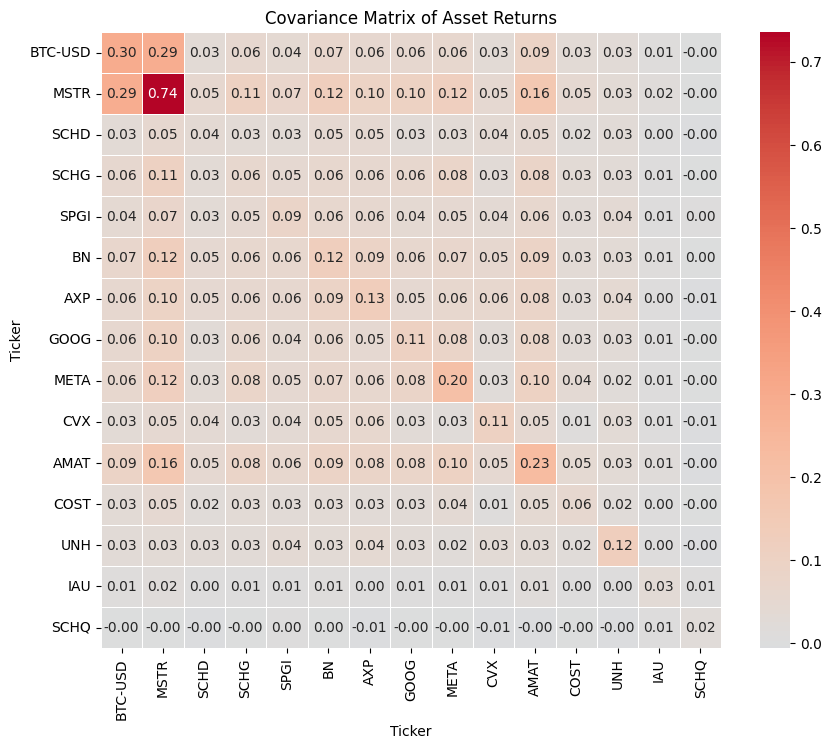

In [168]:
cov_matrix = returns.cov() * 252

plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Covariance Matrix of Asset Returns')
plt.show()

## 4. Correlation Matrix
Normalized covariance — easier to interpret across assets.

$$\rho_{ij} = \frac{\Sigma_{ij}}{\sigma_i \sigma_j}$$

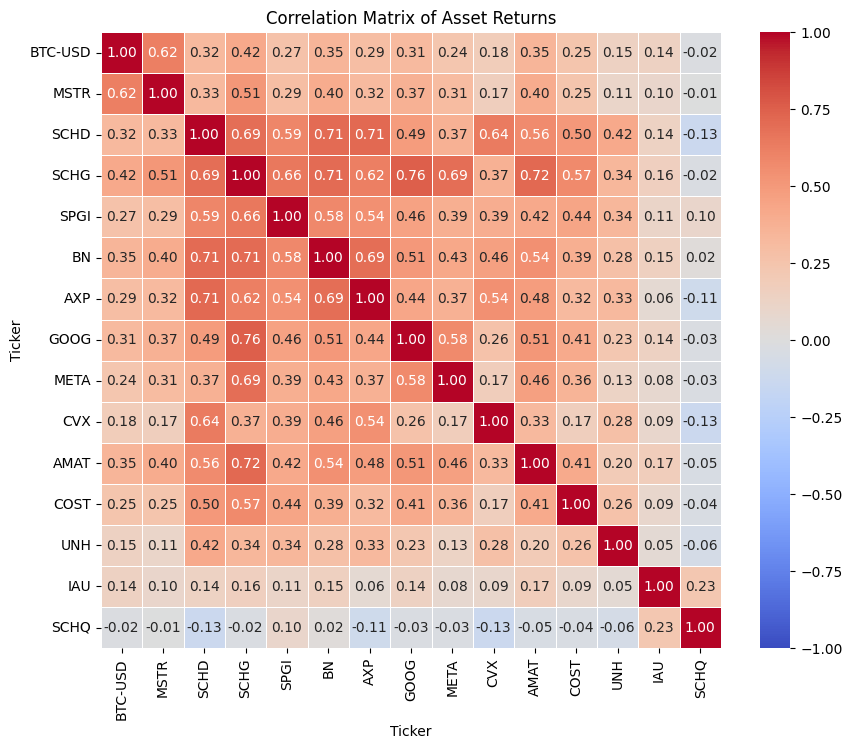

In [169]:
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Correlation Matrix of Asset Returns')
plt.show()

## 5. Efficient Frontier
Plot the set of optimal portfolios for a given level of risk.

$$\min_w \quad w^\top \Sigma w$$

$$\text{subject to} \quad w^\top \mu = \mu^* \quad \text{and} \quad \sum w_i = 1$$

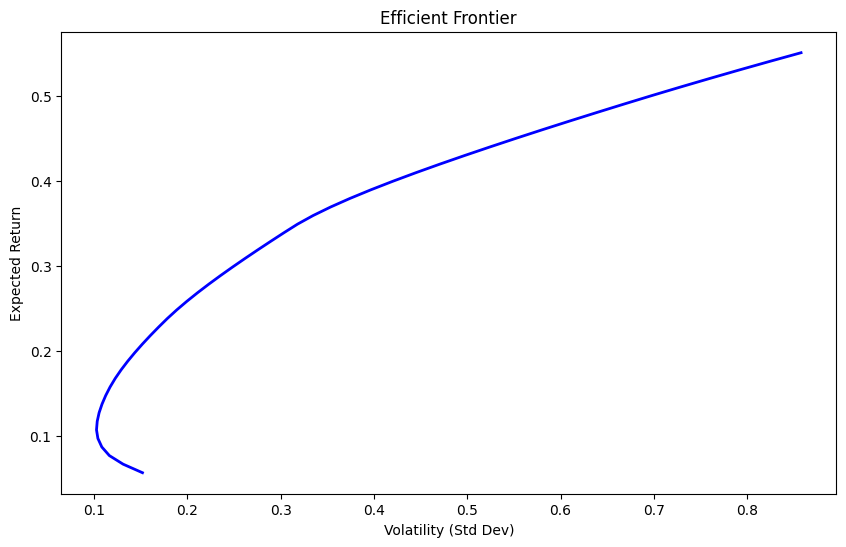

In [170]:
import numpy as np
from scipy.optimize import minimize

expected_returns = returns.mean() * 252

n = len(tickers)
results = []

for target_return in np.linspace(expected_returns.min(), expected_returns.max(), 50):
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, r=target_return: w @ expected_returns.values - r}
    ]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n

    result = minimize(
        lambda w: w @ cov_matrix.values @ w,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        vol = np.sqrt(result.fun)
        results.append((vol, target_return))

vols, rets = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(vols, rets, 'b-', linewidth=2)
plt.xlabel('Volatility (Std Dev)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.show()

## 6. Maximum Sharpe Portfolio

Find the portfolio weights that maximize return per unit of risk.
$$\max_w \quad \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}}$$

In [171]:
import sys
sys.path.append('..')

from src.optimize import max_sharpe

weights = max_sharpe(expected_returns, cov_matrix)
print(dict(zip(tickers, weights.round(4))))

{'BTC-USD': np.float64(0.0638), 'MSTR': np.float64(0.0128), 'SCHD': np.float64(0.0), 'SCHG': np.float64(0.0), 'SPGI': np.float64(0.0), 'BN': np.float64(0.1041), 'AXP': np.float64(0.0185), 'GOOG': np.float64(0.1895), 'META': np.float64(0.0), 'CVX': np.float64(0.0), 'AMAT': np.float64(0.0), 'COST': np.float64(0.1794), 'UNH': np.float64(0.0271), 'IAU': np.float64(0.3689), 'SCHQ': np.float64(0.0359)}


## 7. Backtest

Simulate historical portfolio performance using the optimal weights.

$$V_t = V_{t-1} \times (1 + r_t)$$

$$\text{CAGR} = \left(\frac{V_T}{V_0}\right)^{\frac{252}{T}} - 1$$

$$\text{Sharpe} = \frac{\bar{r}_p - r_f}{\sigma_p}$$

$$\text{Max Drawdown} = \min_t \frac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}$$

{'CAGR': np.float64(0.2346), 'Volatility': np.float64(0.1668), 'Sharpe Ratio': np.float64(1.1077), 'Max Drawdown': np.float64(-0.1983), 'Final Value': np.float64(2.8848)}


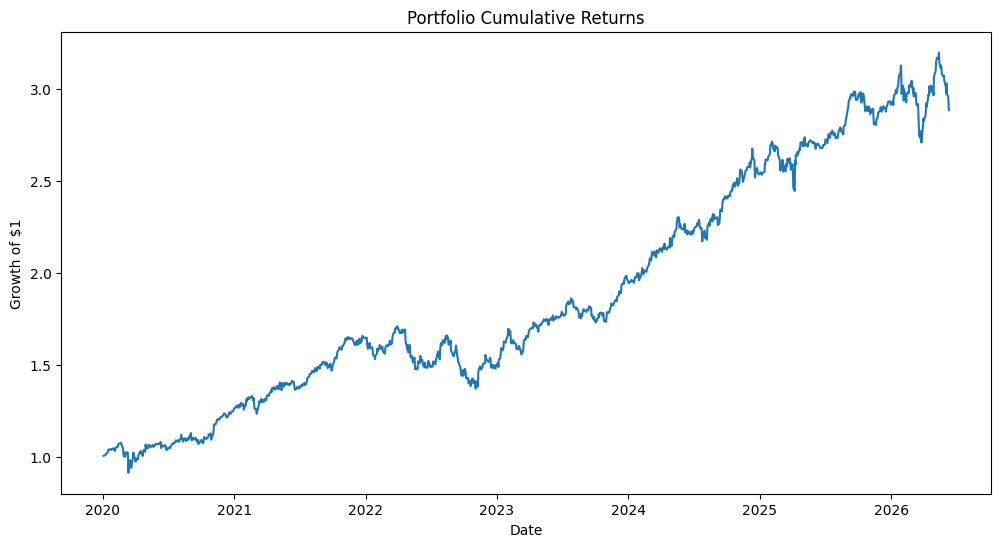

In [172]:
from src.backtest import backtest
import matplotlib.pyplot as plt

portfolio_returns, cumulative_returns, metrics = backtest(returns, weights)

print(metrics)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns)
plt.title('Portfolio Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.show()

## 8. Price Target Optimization

Derive expected returns from 5-year price targets and reoptimize the portfolio.

$$r_i = \left(\frac{P_{i,\text{target}}}{P_{i,\text{current}}}\right)^{\frac{1}{5}} - 1$$

In [173]:
# Entire Portfolio View
price_targets = {
    'BTC-USD': 250000,
    'MSTR': 600,
    'SCHD': 40,
    'SCHG': 60,
    'SPGI': 900,
    'BN': 90,
    'AXP': 650,
    'GOOG': 600,
    'META': 1600,
    'CVX': 250,
    'AMAT': 600,
    'COST': 1000,
    'UNH': 550,
    'IAU': 120,
    'SCHQ': 35
}

dividends = {
    'SCHD': 0.0321,
    'SCHG': 0.0034,
    'SCHQ': 0.0500
}

current_prices = prices.ffill().iloc[-1]

view_returns = {}
for ticker, target in price_targets.items():
    current_price = current_prices[ticker]
    price_return = (target / current_price) ** (1/5) - 1
    dividend_yield = dividends.get(ticker, 0)
    view_returns[ticker] = price_return + dividend_yield
    
for ticker, r in view_returns.items():
    print(f"{ticker}: {r:.2%}")

BTC-USD: 31.87%
MSTR: 38.92%
SCHD: 7.46%
SCHG: 13.10%
SPGI: 16.85%
BN: 15.20%
AXP: 15.85%
GOOG: 11.67%
META: 23.28%
CVX: 5.66%
AMAT: 2.37%
COST: 0.39%
UNH: 6.24%
IAU: 9.35%
SCHQ: 7.51%


## 9. Price Target Portfolio Optimization

Reoptimize using view returns as expected returns.

In [174]:
import pandas as pd

view_returns_series = pd.Series(view_returns)
weights = max_sharpe(view_returns_series, cov_matrix)
print(dict(zip(tickers, weights.round(2))))

{'BTC-USD': np.float64(0.16), 'MSTR': np.float64(0.01), 'SCHD': np.float64(0.0), 'SCHG': np.float64(0.0), 'SPGI': np.float64(0.15), 'BN': np.float64(0.0), 'AXP': np.float64(0.03), 'GOOG': np.float64(0.0), 'META': np.float64(0.13), 'CVX': np.float64(0.0), 'AMAT': np.float64(0.0), 'COST': np.float64(0.0), 'UNH': np.float64(0.0), 'IAU': np.float64(0.22), 'SCHQ': np.float64(0.31)}


In [175]:
roth_tickers = ['SCHG', 'SCHQ']
roth_returns = returns[roth_tickers]
roth_cov_matrix = roth_returns.cov() * 252

roth_view_returns = pd.Series({
    ticker: view_returns[ticker] for ticker in roth_tickers
})

roth_weights = max_sharpe(roth_view_returns, roth_cov_matrix)

print("Roth IRA Optimal Weights:")
for ticker, weight in zip(roth_tickers, roth_weights):
    print(f"{ticker}: {weight:.2%}")

Roth IRA Optimal Weights:
SCHG: 48.85%
SCHQ: 51.15%


In [176]:
import numpy as np

view_returns_series = pd.Series(view_returns)
weights = max_sharpe(view_returns_series, cov_matrix)

port_return = weights @ view_returns_series
port_vol = np.sqrt(weights @ cov_matrix @ weights)
rf = 0.04
sharpe = (port_return - rf) / port_vol

print("\n--- Optimized Allocations ---")
for ticker, w in zip(tickers, weights.round(4)):
    print(f"  {ticker}: {w:.2%}")

print(f"\nExpected Return: {port_return:.2%}")
print(f"Expected Volatility: {port_vol:.2%}")
print(f"Sharpe Ratio: {sharpe:.4f}")


--- Optimized Allocations ---
  BTC-USD: 15.65%
  MSTR: 0.94%
  SCHD: 0.00%
  SCHG: 0.00%
  SPGI: 15.49%
  BN: 0.00%
  AXP: 2.66%
  GOOG: 0.00%
  META: 12.80%
  CVX: 0.00%
  AMAT: 0.00%
  COST: 0.00%
  UNH: 0.00%
  IAU: 21.67%
  SCHQ: 30.79%

Expected Return: 15.70%
Expected Volatility: 16.85%
Sharpe Ratio: 0.6948
